321302 17


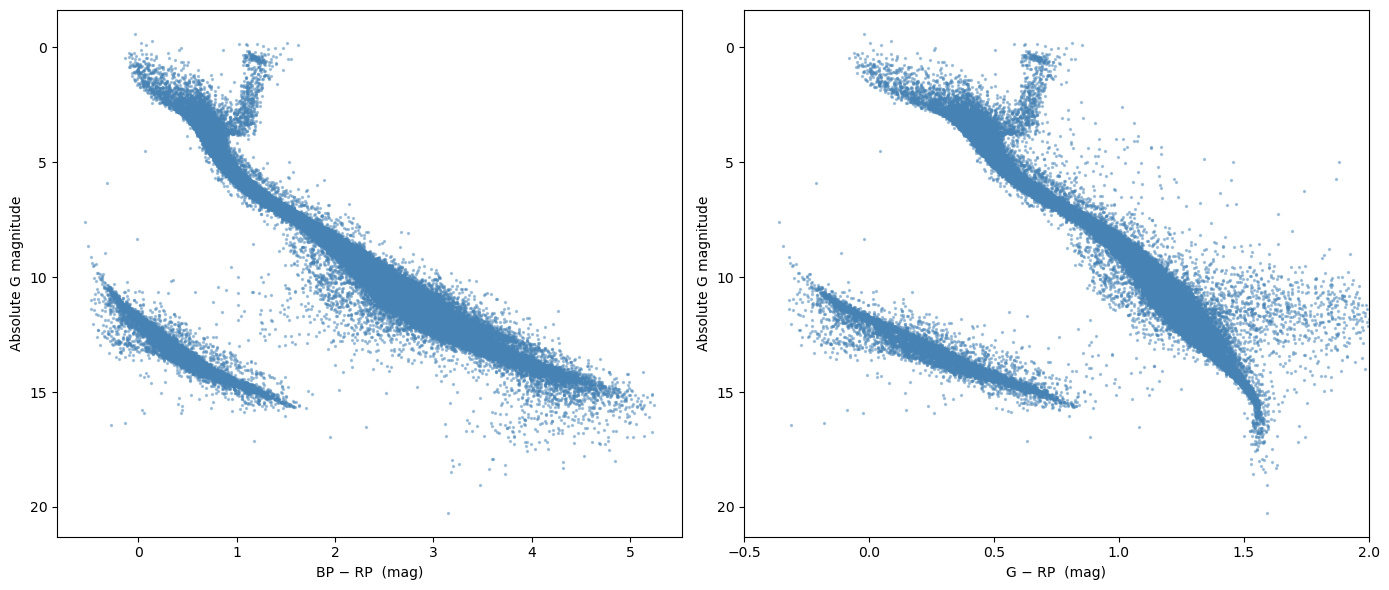

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

df = pd.read_csv("LolaGaiaQuery-result.csv")
print(df.shape[0], df.shape[1])
id = (df['parallax_over_error'] > 100) & (df['ruwe'] < 1.05) 
#Compute distance in parsec from parallax in mas
df["dist_pc"]  = 1000.0 / df["parallax"]
#Compute absolute magnitude in G band (abs_g) from apparent magnitude ("phot_g_mean_mag") and distance modulus
distMod= 5.0 -5.0 * np.log10(1000/df['parallax']) 
df["abs_g"]    = df["phot_g_mean_mag"] + distMod
#The absolute magnitude is the apparent magnitude the star would have if it were all located at a distance of 10 parsec.
df = df[id]

fig, axs = plt.subplots(1,2,figsize=(14, 6))
ax=axs[0]
ax.scatter(df["bp_rp"], df["abs_g"], s=2, alpha=0.4, c="steelblue")
ax.invert_yaxis()
ax.set_xlabel("BP − RP  (mag)")
ax.set_ylabel("Absolute G magnitude")
#ax.set_title("Color-Magnitude Diagram — Gaia DR3 stars within 50 pc")

ax=axs[1]
ax.scatter(df["g_rp"], df["abs_g"], s=2, alpha=0.4, c="steelblue")
ax.invert_yaxis()
ax.set_xlabel("G − RP  (mag)")
ax.set_xlim(-0.5, 2.)
ax.set_ylabel("Absolute G magnitude")
#ax.set_title("Color-Magnitude Diagram — Gaia DR3 stars within 50 pc")
plt.tight_layout()
plt.savefig("color_magnitude_diagram_100pc_scatter.pdf", dpi=300)

In [5]:
plot_2d_correl=True
nbinx,nbiny = 150,150

#  xkeylbl,xkeyunit,xkey, xscale, xmin, xmax, vlines
correl=    ([
      (f'Color (Bp - Rp)', ''      , f'bp_rp'      ,'linear',-1.,6,[]),
      (f'Color (G - Rp)', ''       , f'g_rp'       ,'linear',-0.5,2.,[]),
      (f'Color (Bp - G)', ''      , f'bp_g'      ,'linear',-0.5,4,[]),],
    [
      (f'Absolute Magnitude (G)', ''       , f'abs_g'       ,'linear',-2.5,21.,[]),
      (f'Absolute Magnitude (G)', ''       , f'abs_g'       ,'linear',-2.5,21,[]),
      (f'Absolute Magnitude (G)', ''       , f'abs_g'       ,'linear',-2.5,21,[]),
        ]
)
title='Color-Magnitude Diagrams — Gaia DR3 stars within 100 pc'

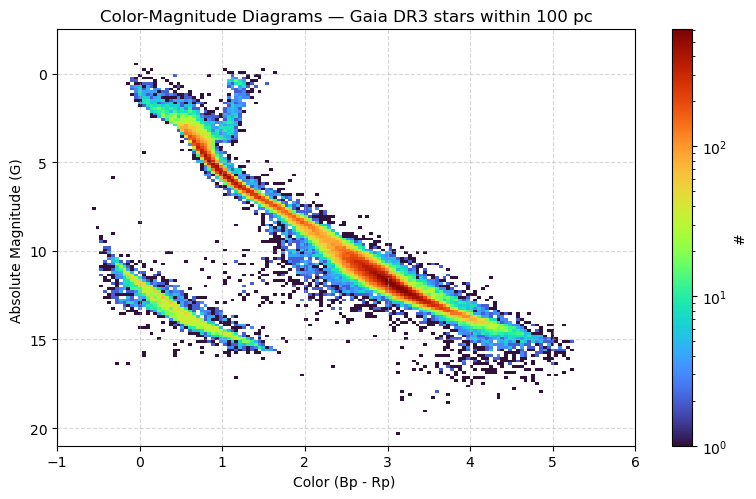

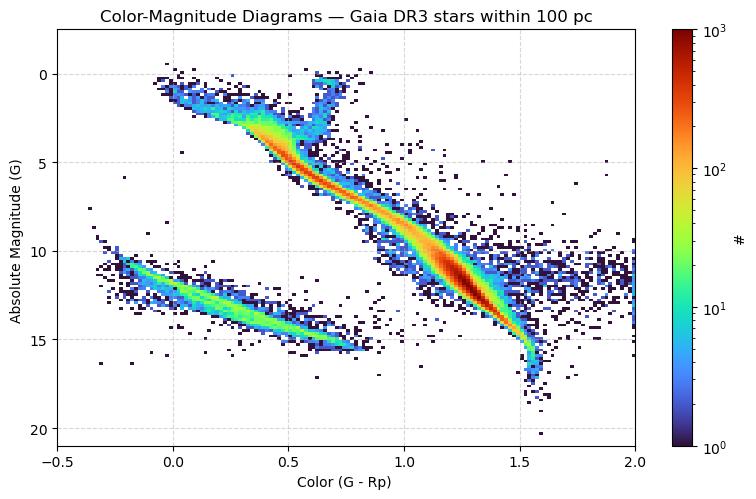

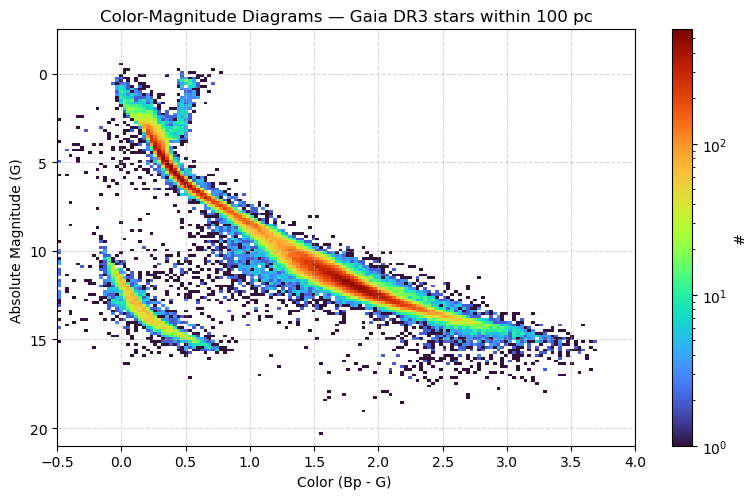

In [6]:
for xs, ys in zip(correl[0],correl[1]):
    xkeylbl,xkeyunit,xkey, xscale, xmin, xmax, vlines=xs
    ykeylbl,ykeyunit,ykey, yscale, ymin, ymax, hlines=ys      
    count=0
    if xmin is None:
        xmin, xmax = np.quantile(df[xkey], [0.01, 0.99])
    if ymin is None:
        min, ymax = np.quantile(df[ykey], [0.01, 0.99])

    fig, ax = plt.subplots(
    1,1, figsize=(8, 5.1)
    )
    ax.set_title(title
      #f'{crit}\n rem. {np.sum(keep)}  (filt. {np.sum(~ind)}, {uniq} unique)'
    )
    _, _, _, im = ax.hist2d(
      df.loc[:, xkey].clip(xmin, xmax),
      df.loc[:, ykey].clip(ymin, ymax),
      bins=(
        10 ** np.linspace(np.log10(xmin), np.log10(xmax), nbinx + 1)
        if xscale == 'log'
        else np.linspace(xmin, xmax, nbinx + 1),
        10 ** np.linspace(np.log10(ymin), np.log10(ymax), nbiny + 1)
        if yscale == 'log'
        else np.linspace(ymin, ymax, nbiny + 1),
      ),
      cmap='turbo',
      norm='log',
      rasterized=True,
    )
    vmin, vmax = im.norm.vmin, im.norm.vmax
    #print(f'check Density plot (vmin,vmax)=({vmin}, {vmax})')
    if vmin!=0 and vmax!=0:
      fig.colorbar(im, ax=ax, label='#')
    ax.set_xlabel(f'{xkeylbl} {xkeyunit}')
    ax.set_ylabel(f'{ykeylbl} {ykeyunit}')

    if xscale == 'log':
      ax.set_xscale('log')
    if yscale == 'log':
      ax.set_yscale('log')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    #plt.title(f'{ykeylbl}_vs_{xkeylbl}')
    ax.grid(which='both', linestyle='--', alpha=0.5)
    if ykey=='abs_g':
        ax.invert_yaxis()

      
    fig.tight_layout()
    fig.savefig(f'color_magnitude_diagram_100pc_{ykey}_vs_{xkey}.pdf')

#    figsaved=fig.copy()
#    axsaved=ax.copy()
